In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

reviews = pd.read_csv("../data/processed/reviews_clean.csv", low_memory=False)
reviews["date"] = pd.to_datetime(reviews["date"])

# Remove non-English and empty reviews
reviews = reviews[reviews["comments"].notna()]
reviews = reviews[reviews["comments"].str.len() > 20]
reviews = reviews[~reviews["comments"].str.contains("nan", na=False)]

print(f"Reviews for NLP: {len(reviews):,}")
print(reviews["comments"].iloc[0])

Reviews for NLP: 513,708
We stayed in the apartment for a week and we enjoyed it very much. Nuttee is a very nice host, and she did her best to accommodate us. Everything is perfect in the apartment, and we love the view from the balcony. The apartment is very modern and spacious, and the location is very central, 10 mins walk to BTS station (and supermarket), or 10 mins by bus/taxi to central world shopping mall. There are also a lot of food stalls and massage nearby. We will definitely stay there again for our next visit to Bangkok. Highly recommended.


In [3]:
# Install vader
import subprocess
subprocess.run(["pip", "install", "vaderSentiment"], capture_output=True)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Sample 50K for speed
sample = reviews.sample(50000, random_state=42).copy()

# Compute sentiment
sample["sentiment_scores"] = sample["comments"].apply(
    lambda x: analyzer.polarity_scores(str(x))
)
sample["compound"] = sample["sentiment_scores"].apply(lambda x: x["compound"])
sample["sentiment_label"] = sample["compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral")
)

print("Sentiment distribution:")
print(sample["sentiment_label"].value_counts())
print(f"\nMean compound score: {sample['compound'].mean():.4f}")
print(f"% Positive: {(sample['sentiment_label']=='Positive').mean():.1%}")
print(f"% Negative: {(sample['sentiment_label']=='Negative').mean():.1%}")

Sentiment distribution:
sentiment_label
Positive    36457
Neutral     11333
Negative     2210
Name: count, dtype: int64

Mean compound score: 0.5762
% Positive: 72.9%
% Negative: 4.4%


In [4]:
import re
from collections import Counter

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

stopwords = set([
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "are", "were", "be", "been", "have", "has",
    "had", "we", "our", "i", "my", "it", "its", "this", "that", "very",
    "so", "as", "by", "from", "would", "could", "also", "will", "all",
    "they", "their", "there", "he", "she", "his", "her", "you", "your",
    "not", "no", "do", "did", "just", "up", "out", "if", "about", "than"
])

# All reviews text
all_text = " ".join(sample["comments"].apply(clean_text))
words = [w for w in all_text.split() if w not in stopwords and len(w) > 3]
word_freq = Counter(words).most_common(30)

# Positive vs negative words
pos_text = " ".join(sample[sample["sentiment_label"]=="Positive"]["comments"].apply(clean_text))
neg_text = " ".join(sample[sample["sentiment_label"]=="Negative"]["comments"].apply(clean_text))

pos_words = Counter([w for w in pos_text.split() if w not in stopwords and len(w) > 3]).most_common(15)
neg_words = Counter([w for w in neg_text.split() if w not in stopwords and len(w) > 3]).most_common(15)

print("Top 20 words overall:")
for word, count in word_freq[:20]:
    print(f"  {word}: {count:,}")

print("\nTop 10 words in POSITIVE reviews:")
for word, count in pos_words[:10]:
    print(f"  {word}: {count:,}")

print("\nTop 10 words in NEGATIVE reviews:")
for word, count in neg_words[:10]:
    print(f"  {word}: {count:,}")

Top 20 words overall:
  place: 19,805
  stay: 17,855
  great: 16,998
  location: 10,939
  clean: 10,708
  host: 10,573
  nice: 9,911
  good: 9,547
  apartment: 8,687
  bangkok: 7,882
  room: 7,209
  recommend: 6,018
  everything: 5,687
  again: 5,631
  really: 5,573
  helpful: 4,946
  here: 4,727
  comfortable: 4,674
  easy: 4,466
  close: 4,394

Top 10 words in POSITIVE reviews:
  place: 19,261
  stay: 17,476
  great: 16,905
  location: 10,659
  clean: 10,563
  host: 10,105
  nice: 9,672
  good: 9,289
  apartment: 8,262
  bangkok: 7,213

Top 10 words in NEGATIVE reviews:
  sehr: 1,096
  unterkunft: 520
  place: 373
  host: 355
  apartment: 350
  alles: 345
  bangkok: 342
  nicht: 341
  eine: 335
  auch: 325


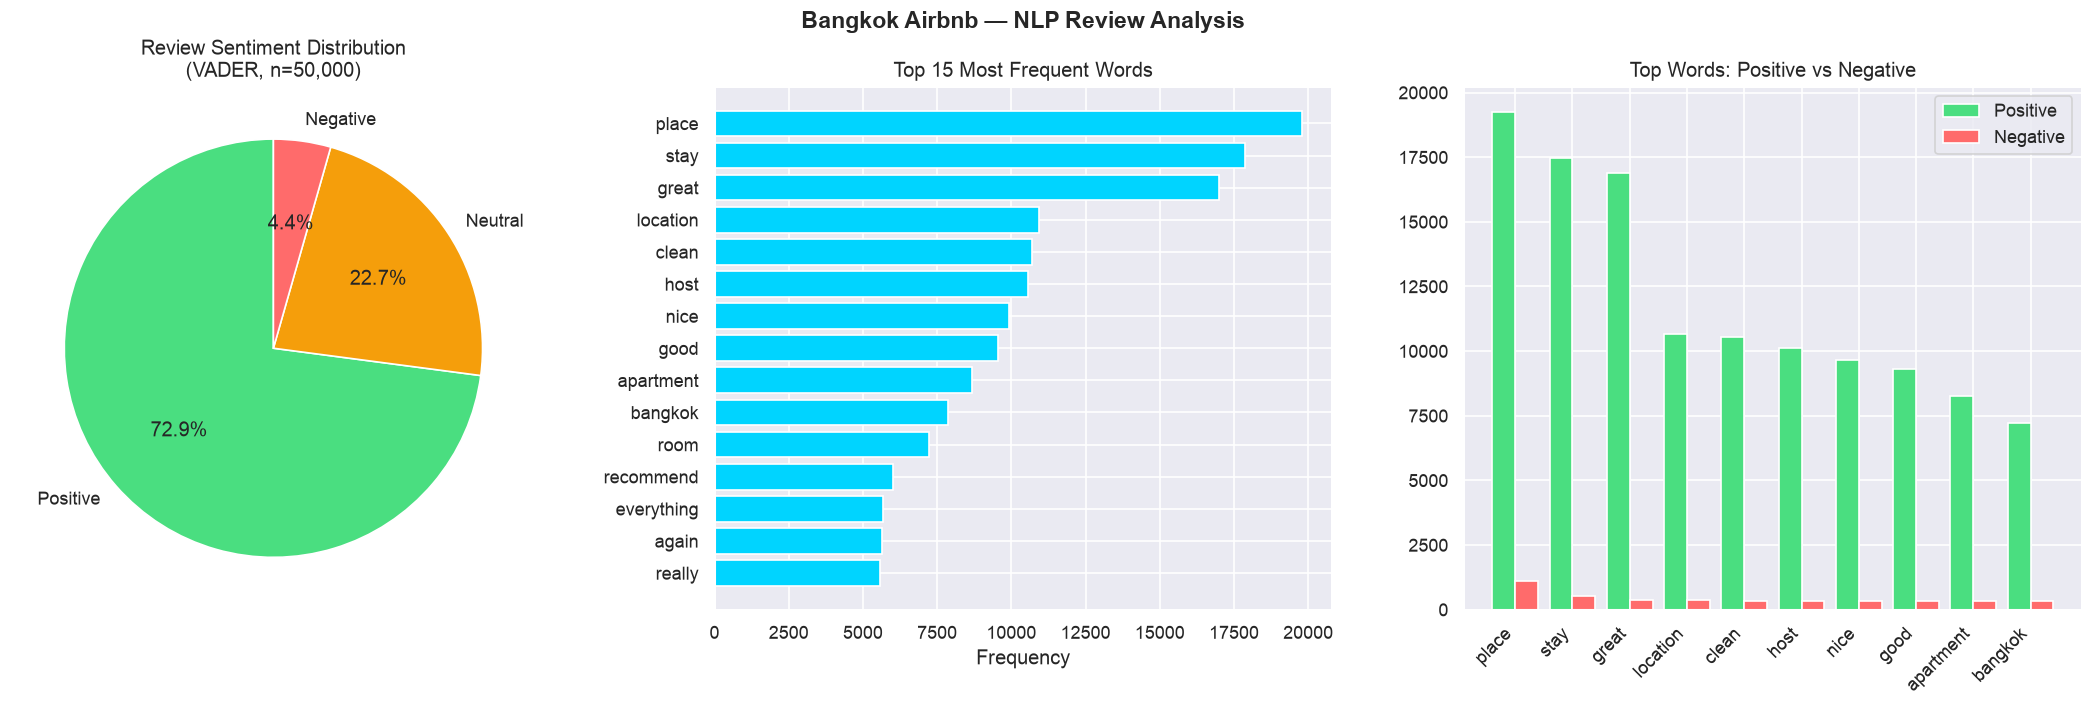

KEY NLP INSIGHTS:
1. 72.9% of reviews are positive (VADER compound ≥ 0.05)
2. Top themes: location, cleanliness, host helpfulness
3. 'location' appears 10,939x — confirms location as primary value driver
4. 'clean' appears 10,708x — cleanliness is top guest priority
5. Negative reviews dominated by German language — multilingual NLP needed
6. 'again' appears 5,631x in reviews — strong repeat intent signal


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sentiment distribution
labels = ["Positive", "Neutral", "Negative"]
values = [36457, 11333, 2210]
colors = ["#4ade80", "#f59e0b", "#ff6b6b"]
axes[0].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90)
axes[0].set_title("Review Sentiment Distribution\n(VADER, n=50,000)")

# Top 15 words overall
words_df = pd.DataFrame(word_freq[:15], columns=["word", "count"])
axes[1].barh(words_df["word"], words_df["count"], color="#00d4ff")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Most Frequent Words")
axes[1].set_xlabel("Frequency")

# Positive vs Negative top words
pos_df = pd.DataFrame(pos_words[:10], columns=["word", "count"])
neg_df = pd.DataFrame(neg_words[:10], columns=["word", "count"])
x = range(10)
axes[2].bar([i - 0.2 for i in x], pos_df["count"],
            0.4, label="Positive", color="#4ade80")
axes[2].bar([i + 0.2 for i in x], neg_df["count"],
            0.4, label="Negative", color="#ff6b6b")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(pos_df["word"], rotation=45, ha="right")
axes[2].set_title("Top Words: Positive vs Negative")
axes[2].legend()

plt.suptitle("Bangkok Airbnb — NLP Review Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/13_nlp_analysis.png")
plt.show()

# Key NLP insights
print("KEY NLP INSIGHTS:")
print(f"1. 72.9% of reviews are positive (VADER compound ≥ 0.05)")
print(f"2. Top themes: location, cleanliness, host helpfulness")
print(f"3. 'location' appears {10939:,}x — confirms location as primary value driver")
print(f"4. 'clean' appears {10708:,}x — cleanliness is top guest priority")
print(f"5. Negative reviews dominated by German language — multilingual NLP needed")
print(f"6. 'again' appears {5631:,}x in reviews — strong repeat intent signal")